In [52]:
import pandas as pd
import numpy as mp
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
listing = pd.read_csv(r"D:\Data Analyst\DA Project-2\Airbnb_Automated_Pipeline_Project\data\processed\clean_listings.csv")
listing.head()

,Unnamed: 0,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,...,review_scores_location,review_scores_value,instant_bookable,price_per_guest,price_per_bedroom,host_experience_years,host_type,luxury_flag,long_stay_flag,overall_avgreview_score
0,0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",no response,1.0,0.98,False,...,10.0,10.0,False,26.5,53.0,14.3,Individual host,Standard,Short stay,22.86
1,1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",no response,1.0,0.98,False,...,10.0,10.0,False,60.0,120.0,12.3,Individual host,Standard,Short stay,22.86
2,2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",no response,1.0,0.98,False,...,10.0,10.0,False,44.5,89.0,11.6,Individual host,Standard,Short stay,22.86
3,3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",no response,1.0,0.98,False,...,10.0,10.0,False,29.0,58.0,12.2,Individual host,Standard,Short stay,22.86
4,4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",no response,1.0,0.98,False,...,10.0,10.0,False,30.0,60.0,11.2,Individual host,Standard,Short stay,22.86


In [54]:
listing.shape

(247882, 41)

In [55]:
listing.info()

<class 'pandas.DataFrame'>
RangeIndex: 247882 entries, 0 to 247881
Data columns (total 41 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   247882 non-null  int64  
 1   listing_id                   247882 non-null  int64  
 2   name                         247732 non-null  str    
 3   host_id                      247882 non-null  int64  
 4   host_since                   247739 non-null  str    
 5   host_location                247882 non-null  str    
 6   host_response_time           247882 non-null  str    
 7   host_response_rate           247882 non-null  float64
 8   host_acceptance_rate         247882 non-null  float64
 9   host_is_superhost            247882 non-null  bool   
 10  host_total_listings_count    247882 non-null  float64
 11  host_has_profile_pic         247882 non-null  bool   
 12  host_identity_verified       247882 non-null  bool   
 13  neighbourh

In [56]:
#Price per Guest
listing["price_per_guest"] = listing["price"]/listing["accommodates"]
listing.head()

,Unnamed: 0,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,...,review_scores_value,instant_bookable,price_per_guest,price_per_bedroom,host_experience_years,overall_review_score,host_type,luxury_flag,long_stay_flag,overall_avgreview_score
0,0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",no response,1.0,0.98,False,...,10.0,False,26.5,53.0,14.3,22.86,Individual host,Standard,Short stay,22.86
1,1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",no response,1.0,0.98,False,...,10.0,False,60.0,120.0,12.3,22.86,Individual host,Standard,Short stay,22.86
2,2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",no response,1.0,0.98,False,...,10.0,False,44.5,89.0,11.6,22.86,Individual host,Standard,Short stay,22.86
3,3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",no response,1.0,0.98,False,...,10.0,False,29.0,58.0,12.2,22.86,Individual host,Standard,Short stay,22.86
4,4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",no response,1.0,0.98,False,...,10.0,False,30.0,60.0,11.2,22.86,Individual host,Standard,Short stay,22.86


In [57]:
listing[["price", "accommodates", "price_per_guest"]].sort_values(by="accommodates", ascending=False).head()

,price,accommodates,price_per_guest
230712,530,16,33.1250
229262,226,16,14.1250
189055,350,16,21.8750
187679,799,16,49.9375
188946,449,16,28.0625


In [58]:
listing["accommodates"].describe()

count    247882.000000
mean          3.092003
std           1.885797
min           1.000000
25%           2.000000
50%           2.000000
75%           4.000000
max          16.000000
Name: accommodates, dtype: float64

In [59]:
#price per bedroom
listing["price_per_bedroom"] = listing["price"]/listing["bedrooms"]
listing[["price", "bedrooms", "price_per_bedroom"]].sort_values(by="bedrooms", ascending=False).head()

,price,bedrooms,price_per_bedroom
74040,550,10.0,55.0
74068,60,10.0,6.0
83319,416,10.0,41.6
185970,242,10.0,24.2
54920,462,10.0,46.2


In [60]:
listing["host_since"] = pd.to_datetime(listing["host_since"])

In [61]:
listing["host_since"].info()

<class 'pandas.Series'>
RangeIndex: 247882 entries, 0 to 247881
Series name: host_since
Non-Null Count   Dtype         
--------------   -----         
247739 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 1.9 MB


In [62]:
listing["host_experience_years"] = (pd.Timestamp.today() - listing["host_since"]).dt.days/365
listing["host_experience_years"] = listing["host_experience_years"].round(1)


In [63]:
review_cols = ["review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin", "review_scores_communication",
    "review_scores_location", "review_scores_value"]

listing["overall_avgreview_score"] = listing[review_cols].mean(axis=1).round(2)

In [64]:
listing["host_type"] = listing["host_total_listings_count"].apply(lambda x: "Individual host" if x<=3 else "Professional host")

In [65]:
listing["luxury_flag"] = listing["price"].apply(lambda x: "Luxury" if x>=500 else "Standard")

In [66]:
listing["long_stay_flag"] = listing["minimum_nights"].apply(lambda x: "Long stay" if x>=30 else "Short stay")

In [67]:
listing[[
    "price",
    "accommodates",
    "price_per_guest",
    "bedrooms",
    "price_per_bedroom",
    "host_since",
    "host_experience_years",
    "overall_avgreview_score",
    "host_type",
    "luxury_flag",
    "long_stay_flag"
]].sort_values(by="price", ascending=False).head()

,price,accommodates,price_per_guest,bedrooms,price_per_bedroom,host_since,host_experience_years,overall_avgreview_score,host_type,luxury_flag,long_stay_flag
187500,1067,4,266.750000,2.0,533.5,2017-02-05,9.1,22.86,Individual host,Luxury,Short stay
189347,1067,4,266.750000,2.0,533.5,2013-01-22,13.1,22.43,Individual host,Luxury,Short stay
232611,1067,2,533.500000,1.0,1067.0,2017-05-11,8.8,22.86,Individual host,Luxury,Short stay
90734,1067,3,355.666667,1.0,1067.0,2017-12-11,8.2,22.29,Individual host,Luxury,Short stay
98548,1067,1,1067.000000,1.0,1067.0,2015-03-19,11.0,22.29,Professional host,Luxury,Short stay


In [68]:
listing["host_total_listings_count"].describe()

count    247882.000000
mean         22.694911
std         264.079071
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max        7235.000000
Name: host_total_listings_count, dtype: float64

In [69]:
listing[listing["host_type"] == "Professional host"].head()

,Unnamed: 0,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,...,review_scores_value,instant_bookable,price_per_guest,price_per_bedroom,host_experience_years,overall_review_score,host_type,luxury_flag,long_stay_flag,overall_avgreview_score
34299,34299,1473337,"Par Amour, 1BR/1BA for 3 people",7642792,2013-07-22,"Paris, Ile-de-France, France",within a few hours,0.92,0.93,False,...,8.0,False,43.000000,129.0,12.6,18.43,Professional host,Standard,Long stay,18.43
34300,34300,1992443,"Burdigala, 1BR/1BA for 3 people",7642792,2013-07-22,"Paris, Ile-de-France, France",within a few hours,0.92,0.93,False,...,10.0,False,42.333333,127.0,12.6,22.86,Professional host,Standard,Long stay,22.86
34301,34301,17689178,"Jason, 1BR/1BA, 3 people",7642792,2013-07-22,"Paris, Ile-de-France, France",within a few hours,0.92,0.93,False,...,10.0,False,48.333333,145.0,12.6,22.86,Professional host,Standard,Long stay,22.86
34302,34302,18406013,Paris - Montmartre/Clignancourt,13013633,2014-03-11,FR,within an hour,0.96,0.97,False,...,7.0,False,21.000000,42.0,12.0,16.86,Professional host,Standard,Short stay,16.86
34303,34303,19463468,Beautiful 1 bedroom balcony Montaigne / Elysees,21630783,2014-09-22,"Paris, Ile-de-France, France",within a day,0.87,0.59,False,...,7.0,False,26.750000,107.0,11.5,19.29,Professional host,Standard,Short stay,19.29


In [70]:
listing[listing["host_type"] == "Professional host"][[
    "price",
    "accommodates",
    "price_per_guest",
    "bedrooms",
    "price_per_bedroom",
    "host_since",
    "host_experience_years",
    "overall_review_score",
    "host_type",
    "luxury_flag",
    "long_stay_flag"
]].head()

,price,accommodates,price_per_guest,bedrooms,price_per_bedroom,host_since,host_experience_years,overall_review_score,host_type,luxury_flag,long_stay_flag
34299,129,3,43.000000,1.0,129.0,2013-07-22,12.6,18.43,Professional host,Standard,Long stay
34300,127,3,42.333333,1.0,127.0,2013-07-22,12.6,22.86,Professional host,Standard,Long stay
34301,145,3,48.333333,1.0,145.0,2013-07-22,12.6,22.86,Professional host,Standard,Long stay
34302,42,2,21.000000,1.0,42.0,2014-03-11,12.0,16.86,Professional host,Standard,Short stay
34303,107,4,26.750000,1.0,107.0,2014-09-22,11.5,19.29,Professional host,Standard,Short stay


In [71]:
listing["host_type"].value_counts()

host_type
Individual host      185474
Professional host     62408
Name: count, dtype: int64

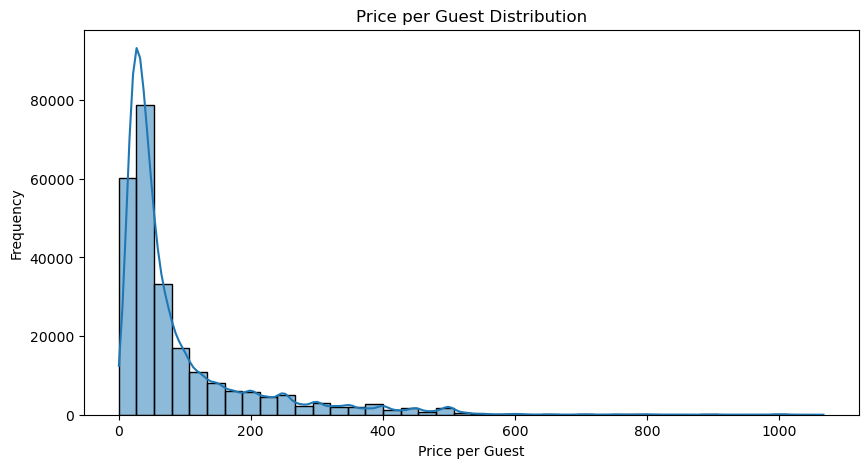

In [72]:
#price per guest distribution
plt.figure(figsize=(10,5))
sns.histplot(listing["price_per_guest"], bins=40, kde=True)
plt.title("Price per Guest Distribution")
plt.xlabel("Price per Guest")
plt.ylabel("Frequency")
plt.show()

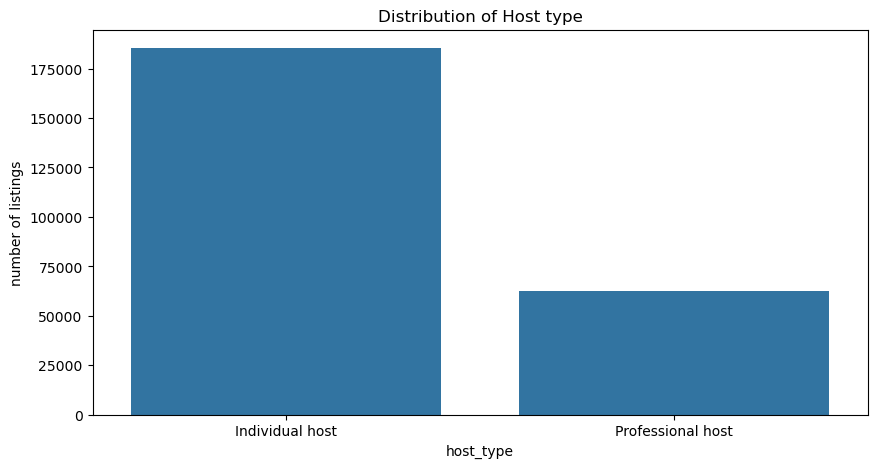

In [73]:
#Professional vs Individual Hosts

plt.figure(figsize=(10,5))
sns.countplot(x="host_type", data=listing)
plt.title("Distribution of Host type")
plt.xlabel("host_type")
plt.ylabel("number of listings")
plt.show()

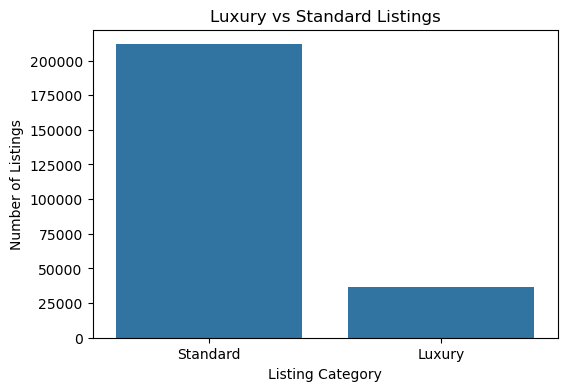

In [74]:
plt.figure(figsize=(6,4))
sns.countplot(x="luxury_flag", data=listing)
plt.title("Luxury vs Standard Listings")
plt.xlabel("Listing Category")
plt.ylabel("Number of Listings")
plt.show()

### Feature Engineering Insights

1. Price per guest distribution shows most listings fall between $20–$80 per guest.

2. Individual hosts dominate the platform, suggesting Airbnb is largely driven by small property owners rather than professional property managers.

3. Standard listings represent the majority of properties, while luxury listings form a smaller niche segment.

4. Price per guest distribution is right-skewed, meaning a few high-priced listings significantly extend the upper tail of the distribution.

In [75]:
listing.drop(columns=["overall_review_score"], inplace=True)

In [84]:
listing = listing.drop(columns=["Unnamed: 0"], errors="ignore")

In [85]:
listing.to_csv(r"D:\Data Analyst\DA Project-2\Airbnb_Automated_Pipeline_Project\data\processed\clean_listings.csv")

In [86]:
listing.info()

<class 'pandas.DataFrame'>
RangeIndex: 247882 entries, 0 to 247881
Data columns (total 39 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   247882 non-null  int64  
 1   name                         247732 non-null  str    
 2   host_id                      247882 non-null  int64  
 3   host_since                   247739 non-null  str    
 4   host_location                247882 non-null  str    
 5   host_response_time           247882 non-null  str    
 6   host_response_rate           247882 non-null  float64
 7   host_acceptance_rate         247882 non-null  float64
 8   host_is_superhost            247882 non-null  bool   
 9   host_total_listings_count    247882 non-null  float64
 10  host_has_profile_pic         247882 non-null  bool   
 11  host_identity_verified       247882 non-null  bool   
 12  neighbourhood                247882 non-null  str    
 13  city      

In [87]:
listing.isnull().sum()

listing_id                       0
name                           150
host_id                          0
host_since                     143
host_location                    0
host_response_time               0
host_response_rate               0
host_acceptance_rate             0
host_is_superhost                0
host_total_listings_count        0
host_has_profile_pic             0
host_identity_verified           0
neighbourhood                    0
city                             0
latitude                         0
longitude                        0
property_type                    0
room_type                        0
accommodates                     0
bedrooms                         0
amenities                        0
price                            0
minimum_nights                   0
maximum_nights                   0
review_scores_rating             0
review_scores_accuracy           0
review_scores_cleanliness        0
review_scores_checkin            0
review_scores_commun

In [88]:
len(listing.columns)

39